In [37]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

In [39]:
image_ds = tf.data.Dataset.list_files("data/kitti/training/image_2/*.png", shuffle=False)
mask_ds = tf.data.Dataset.list_files("data/kitti/training/semantic/*.png", shuffle=False)
dataset = tf.data.Dataset.zip((image_ds, mask_ds))

In [40]:
for path in image_ds.take(5):
    print(path.numpy())

b'data/kitti/training/image_2/000000_10.png'
b'data/kitti/training/image_2/000001_10.png'
b'data/kitti/training/image_2/000002_10.png'
b'data/kitti/training/image_2/000003_10.png'
b'data/kitti/training/image_2/000004_10.png'


In [41]:
for path in mask_ds.take(5):
    print(path.numpy())

b'data/kitti/training/semantic/000000_10.png'
b'data/kitti/training/semantic/000001_10.png'
b'data/kitti/training/semantic/000002_10.png'
b'data/kitti/training/semantic/000003_10.png'
b'data/kitti/training/semantic/000004_10.png'


In [42]:
from data.devkit_semantics.devkit.helpers.labels import labels

mapping = np.full(256, 255, dtype=np.int32)
for label in labels:
    if label.id >= 0:
        mapping[label.id] = label.trainId
mapping[mapping == 255] = 19

In [43]:
def load_preprocess(image_path, mask_path):
    raw_image = tf.io.read_file(image_path)
    raw_mask = tf.io.read_file(mask_path)

    decoded_image = tf.image.decode_png(raw_image, channels=3)
    decoded_mask = tf.image.decode_png(raw_mask, channels=1)

    resized_image = tf.image.resize(decoded_image, [128,384])
    resized_mask = tf.image.resize(decoded_mask, [128,384], method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)

    label_mapping = tf.constant(mapping, dtype=tf.int32)
    resized_mask = tf.gather(label_mapping, tf.cast(resized_mask, tf.int32))

    resized_image = resized_image / 255.0

    return resized_image, resized_mask

In [44]:
dataset = dataset.map(load_preprocess)

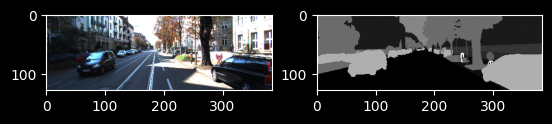

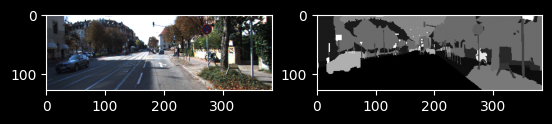

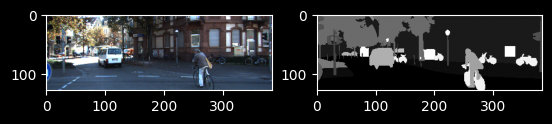

In [45]:
for feature, label in dataset.take(3):
    fig, (ax1, ax2) = plt.subplots(1, 2)
    ax1.imshow(feature)
    ax2.imshow(tf.squeeze(label), cmap='gray')
    plt.show()

In [46]:
batch_size = 8
train_ds = dataset.take(160).shuffle(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = dataset.skip(160).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [47]:
import importlib
import unet
importlib.reload(unet)
from unet import build_unet

In [48]:
model = build_unet((128,384, 3), 20)
model.summary()

Model: "unet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 384,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 128, 384,  │      1,792 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 128, 384,  │     36,928 │ conv2d_38[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 64, 192,   │          0 │ conv2d_39[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 192,   │     73,856 │ max_pooling2d_8[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 192,   │    147,584 │ conv2d_40[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 32, 96,    │          0 │ conv2d_41[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 32, 96,    │    295,168 │ max_pooling2d_9[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 32, 96,    │    590,080 │ conv2d_42[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 16, 48,    │          0 │ conv2d_43[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 16, 48,    │  1,180,160 │ max_pooling2d_10… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 16, 48,    │  2,359,808 │ conv2d_44[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 8, 24,     │          0 │ conv2d_45[0][0]   │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 8, 24,     │  4,719,616 │ max_pooling2d_11… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_47 (Conv2D)  │ (None, 8, 24,     │  9,438,208 │ conv2d_46[0][0]   │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_8  │ (None, 16, 48,    │  2,097,664 │ conv2d_47[0][0]   │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_8       │ (None, 16, 48,    │          0 │ conv2d_transpose

 Total params: 31,032,980 (118.38 MB)

 Trainable params: 31,032,980 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        'accuracy',
        tf.keras.metrics.MeanIoU(num_classes=20, sparse_y_pred=False, ignore_class=19)
    ]
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[tf.keras.callbacks.TensorBoard(log_dir='logs/lr_0.001')]
)

model.save('checkpoints/baseline_lr001_20epochs.keras')

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 819ms/step - accuracy: 0.2248 - loss: 2.5690 - mean_io_u_7: 0.0253 - val_accuracy: 0.4004 - val_loss: 2.0914 - val_mean_io_u_7: 0.0368
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 16s 809ms/step - accuracy: 0.4763 - loss: 1.8276 - mean_io_u_7: 0.0669 - val_accuracy: 0.4215 - val_loss: 2.1129 - val_mean_io_u_7: 0.0447
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 826ms/step - accuracy: 0.5118 - loss: 1.7305 - mean_io_u_7: 0.0735 - val_accuracy: 0.5172 - val_loss: 1.7565 - val_mean_io_u_7: 0.0826
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 18s 895ms/step - accuracy: 0.5838 - loss: 1.4730 - mean_io_u_7: 0.0962 - val_accuracy: 0.5644 - val_loss: 1.5793 - val_mean_io_u_7: 0.0926
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6138 - loss: 1.3315 - mean_io_u_7: 0.1105 - val_accuracy: 0.5832 - val_loss: 1.4758 - val_mean_io_u_7: 0.1075
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.6552 - loss: 1.1735 - mean_io_u_7: 0.1315 - val_accura

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step


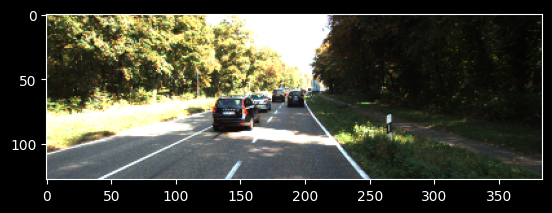

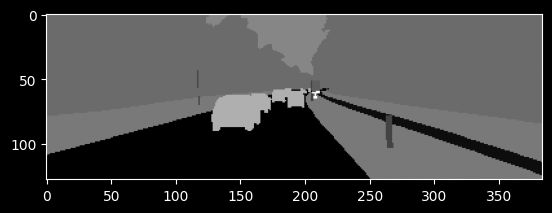

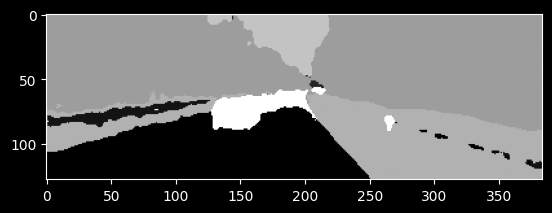

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step


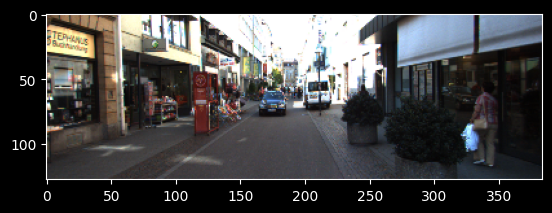

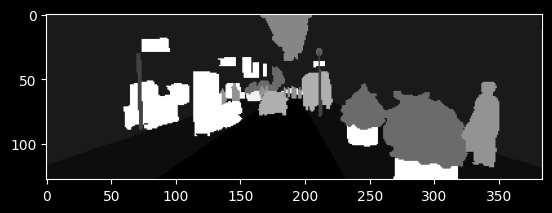

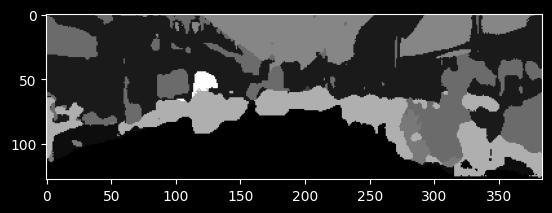

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step


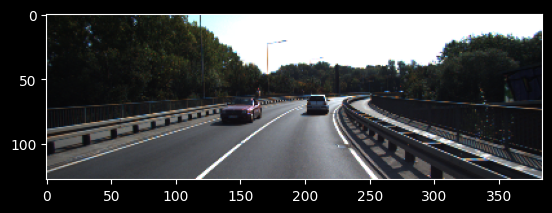

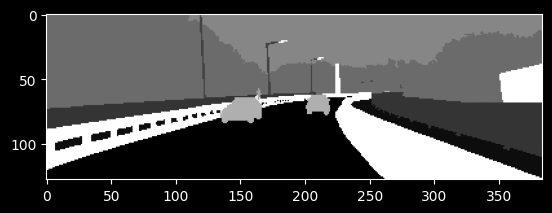

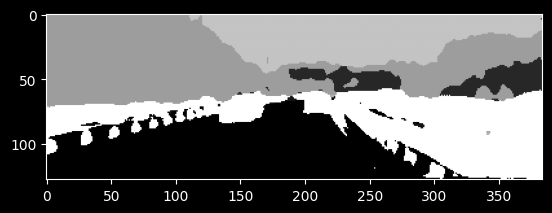

In [50]:
for image, mask in val_ds.take(3):
    prediction = model.predict(image)
    predicted_mask = tf.argmax(prediction, axis=-1)

    plt.imshow(image[0])
    plt.show()
    plt.imshow(tf.squeeze(mask[0]), cmap='gray')
    plt.show()
    plt.imshow(predicted_mask[0], cmap='gray')
    plt.show()